# FJSP ANALYSIS

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [3]:
df = pd.read_csv('final_results.csv')


In [4]:
print(df.head(2))

             timestamp instance_name  n_jobs  n_machines  n_operations  \
0  2026-10-01 12:08:25       behnke1      10          20            50   
1  2026-10-01 12:08:27       behnke2      10          20            50   

   avg_ops_per_job   beta     dv  eligibility_entropy  processing_gap_ratio  \
0              5.0  0.304  0.069                0.986                 0.453   
1              5.0  0.336  0.062                0.980                 0.479   

   ...  bottleneck_intensity  optimal_algorithm          selection_reason  \
0  ...                 1.097   CP-SAT (OPTIMAL)  CP-SAT OPTIMAL and VALID   
1  ...                 1.088   CP-SAT (OPTIMAL)  CP-SAT OPTIMAL and VALID   

   status makespan runtime_seconds bks_lower_bound  bks_upper_bound  \
0   VALID       90            1.44              90               90   
1   VALID       91            1.03              91               91   

   bks_gap_pct                                      instance_path  
0          0.0  benchmark

In [5]:
new_df = df.iloc[:, :-1]


In [6]:
new_df = df.iloc[:, 2:]


In [7]:
print(new_df.head(2))

   n_jobs  n_machines  n_operations  avg_ops_per_job   beta     dv  \
0      10          20            50              5.0  0.304  0.069   
1      10          20            50              5.0  0.336  0.062   

   eligibility_entropy  processing_gap_ratio  time_skew  bottleneck_metric  \
0                0.986                 0.453      0.281              0.819   
1                0.980                 0.479      0.269              0.894   

   ...  bottleneck_intensity  optimal_algorithm          selection_reason  \
0  ...                 1.097   CP-SAT (OPTIMAL)  CP-SAT OPTIMAL and VALID   
1  ...                 1.088   CP-SAT (OPTIMAL)  CP-SAT OPTIMAL and VALID   

  status makespan  runtime_seconds  bks_lower_bound  bks_upper_bound  \
0  VALID       90             1.44               90               90   
1  VALID       91             1.03               91               91   

   bks_gap_pct                                      instance_path  
0          0.0  benchmarks/flexible-j

In [8]:
new_df['optimal_algorithm'] = new_df['optimal_algorithm'].map({
    'CP-SAT (OPTIMAL)': 0,
    'CP-SAT (FEASIBLE)': 1,
    'Hybrid (best of 4 seeds)':2
})

In [9]:
new_df['selection_reason'] = new_df['selection_reason'].map({
    'CP-SAT OPTIMAL and VALID': 0,
    'CP-SAT FEASIBLE no worse than best hybrid seed 0': 1,
    'Best hybrid seed 0 beat CP-SAT FEASIBLE':2,
    'Hybrid fallback after CP-SAT found no feasible schedule':3
})

In [10]:
print(new_df.head(10))

   n_jobs  n_machines  n_operations  avg_ops_per_job   beta     dv  \
0      10          20            50              5.0  0.304  0.069   
1      10          20            50              5.0  0.336  0.062   
2      10          20            50              5.0  0.312  0.067   
3      10          20            50              5.0  0.332  0.063   
4      10          20            50              5.0  0.308  0.068   
5      20          20           100              5.0  0.334  0.031   
6      20          20           100              5.0  0.326  0.032   
7      20          20           100              5.0  0.322  0.033   
8      20          20           100              5.0  0.322  0.033   
9      20          20           100              5.0  0.306  0.034   

   eligibility_entropy  processing_gap_ratio  time_skew  bottleneck_metric  \
0                0.986                 0.453      0.281              0.819   
1                0.980                 0.479      0.269              0.89

In [11]:
new_df['status'] = new_df['status'].map({
    'VALID': 1,
    'INVALID':0
})

In [12]:
print((new_df['status'] == 0).sum())


4


These 4 instances are orb7.txt inside HurinkJurishThole instances where processing time in last operation for some machine is 0.Hence our validator rejected this schedule

In [13]:
new_df = new_df.iloc[:, :-1]

In [14]:
m=new_df.corr()
print(m)

                        n_jobs  n_machines  n_operations  avg_ops_per_job  \
n_jobs                1.000000    0.522774      0.789276        -0.148260   
n_machines            0.522774    1.000000      0.350775        -0.142232   
n_operations          0.789276    0.350775      1.000000         0.441605   
avg_ops_per_job      -0.148260   -0.142232      0.441605         1.000000   
beta                 -0.020061   -0.049000     -0.216113        -0.380405   
dv                   -0.439388   -0.523935     -0.521647        -0.207355   
eligibility_entropy  -0.058460   -0.039181     -0.017903         0.063786   
processing_gap_ratio -0.480964   -0.712680     -0.166079         0.422431   
time_skew             0.422747    0.622110      0.124365        -0.413230   
bottleneck_metric     0.212992    0.283994      0.079677        -0.201322   
bottleneck_coverage   0.349441    0.487229      0.182731        -0.211450   
bottleneck_intensity  0.093520    0.111008      0.000831        -0.166329   

In [15]:
import seaborn as sns


In [16]:
corr = new_df.corr(numeric_only=True)["bks_gap_pct"]

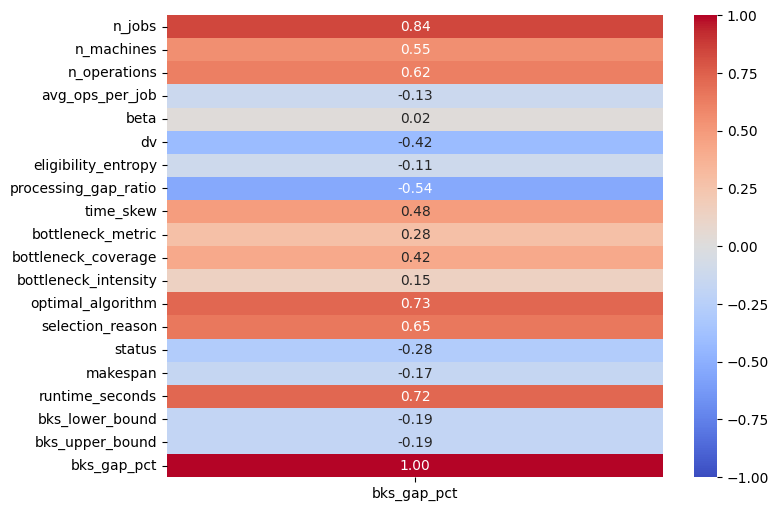

In [17]:
plt.figure(figsize=(8, 6))
sns.heatmap(corr.to_frame(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.show()

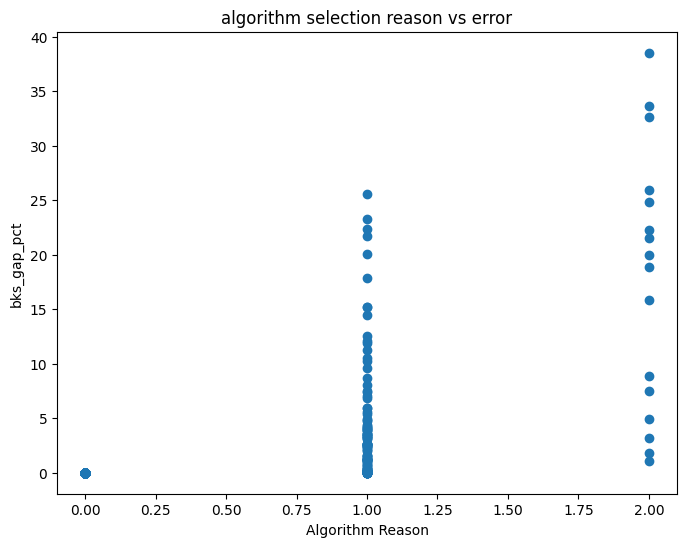

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(new_df['selection_reason'], new_df['bks_gap_pct'])

plt.xlabel('Algorithm Reason')
plt.ylabel('bks_gap_pct')
plt.title('algorithm selection reason vs error')
plt.show()
# 0->CP SAT VALID
# 1->CP SAT FEASIBLE AND BETTER
# 2->CP SAT FEASIBLE BUT HYBRID BETTER
# 3->CP SAT CANNOT FIND SCHEDULE,HYBRID's ERROR

- If CP-SAT is able to find the optimal and valid schedule in given time->Best answer achieved. As the need of using hybrid increases, error percentage also increases

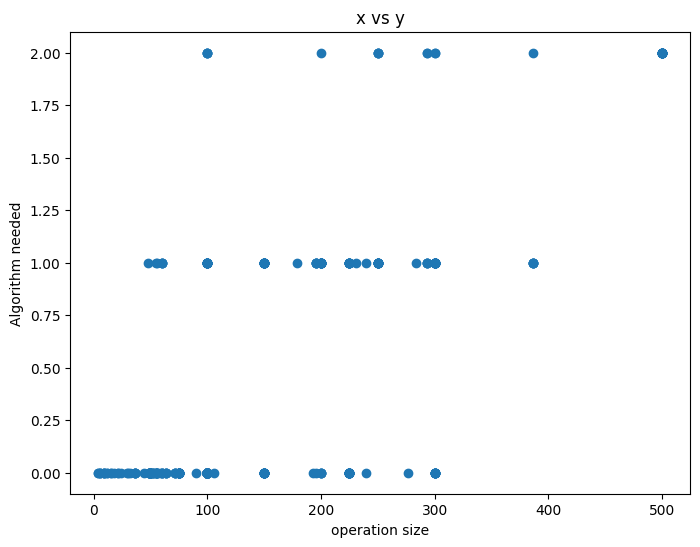

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(new_df['n_operations'],new_df['optimal_algorithm'])

plt.xlabel('operation size')
plt.ylabel('Algorithm needed')
plt.title('x vs y')
plt.show()

As no of operations increase, need of hybrid increases as CP sat finds difficult to prove its solution optimal

# NOTE
Since algorithm choices and error percentage evidently depends a lot on number of operations and number of jobs, we compare 2 or 3 metrics simultaneously to find useful correlations.

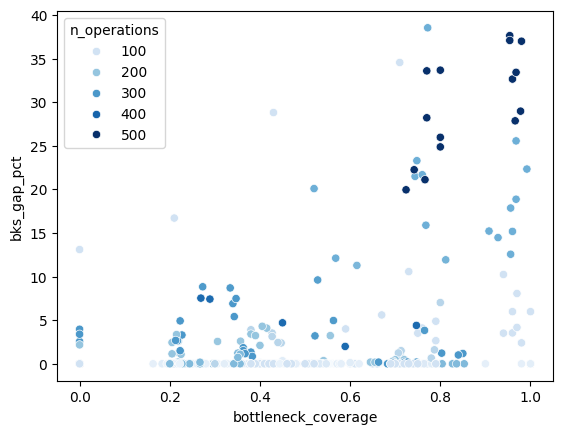

In [20]:
sns.scatterplot(data=new_df, x='bottleneck_coverage', y='bks_gap_pct', hue='n_operations', palette='Blues')
plt.show()

It is evident that error percentage increases as number of operations increase but apart from it, there are many instances where no of operations are low-moderate but error percentage is high because of high bottleneck coverage


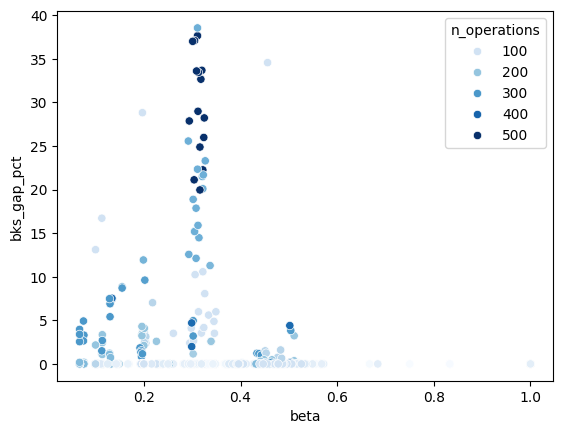

In [21]:
sns.scatterplot(data=new_df, x='beta', y='bks_gap_pct', hue='n_operations', palette='Blues')
plt.show()

Even with low number of operations, algorithm struggles at finding optimial solution for beta around 0.2-0.3.


Problem->Dataset contains low values of high beta and high number of operations to find any useful correlation

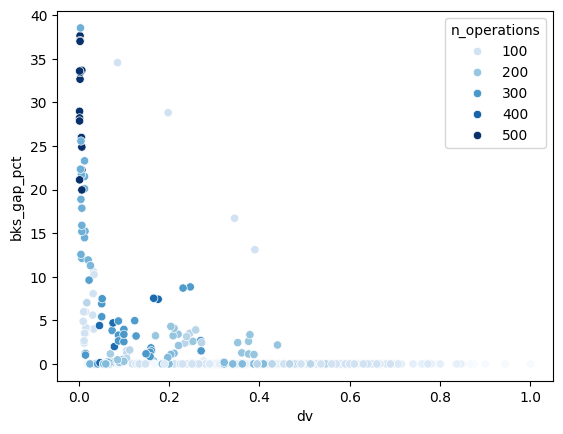

In [22]:
sns.scatterplot(data=new_df, x='dv', y='bks_gap_pct', hue='n_operations', palette='Blues')
plt.show()

Our algorithm evidently struggles with instances which simultaneously have Low dv values with high number of operations.


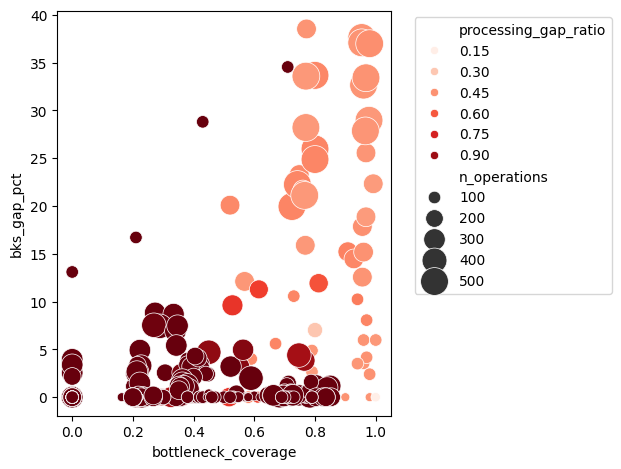

In [23]:
sns.scatterplot(
    data=new_df, 
    x='bottleneck_coverage', 
    y='bks_gap_pct', 
    hue='processing_gap_ratio', 
    size='n_operations', 
    palette='Reds',
    sizes=(5, 400) 
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

For high processing gap ratio and low bottleneck coverage,even for moderate-high number of operation,error percentage is less.But for small processing gap ratio, high bottleneck coverage, error increases, even for small-moderate sized instances 

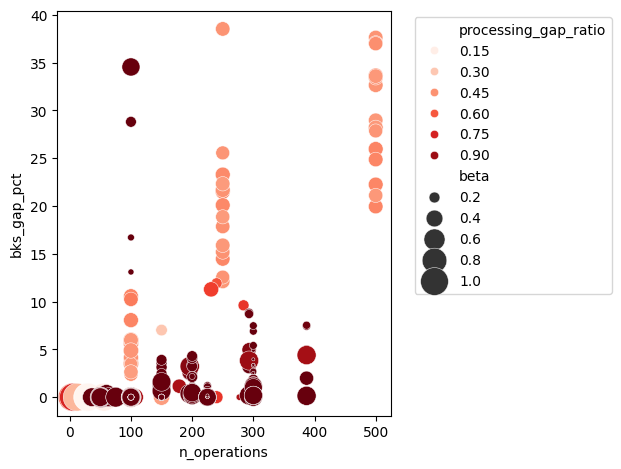

In [24]:
sns.scatterplot(
    data=new_df, 
    x='n_operations', 
    y='bks_gap_pct', 
    hue='processing_gap_ratio', 
    size='beta', 
    palette='Reds',
    sizes=(5, 400) 
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Even with moderate-high number of operations(300-400), if instance has a high processing gap ratio and less number of avg eligible machines per operation(2-4), algorothm is able to identify close to optimal schedule 

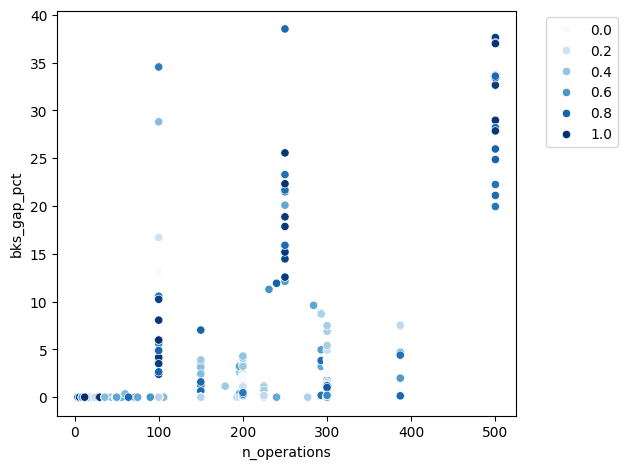

In [25]:
sns.scatterplot(
    data=new_df, 
    x='n_operations', 
    y='bks_gap_pct', 
    hue='bottleneck_coverage', 
    palette='Blues',
    sizes=(5, 400) 
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Even with moderate-high number of operations(300-400), if instance has low bottleneck coverage(less than 0.5-0.6), model can predict a good schedule. As bottleneck coverage increases, algorithm faces difficulty.Even for 100 operations, high bottleneck coverage instances are prone to 5-10% error.

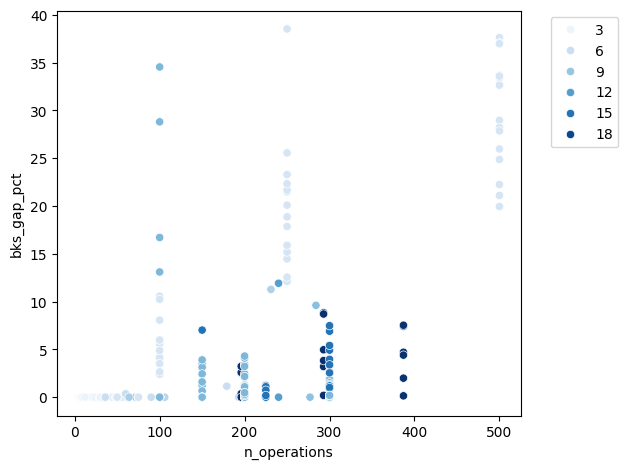

In [29]:
sns.scatterplot(
    data=new_df, 
    x='n_operations', 
    y='bks_gap_pct', 
    hue='avg_ops_per_job', 
    palette='Blues',
    sizes=(5, 400) 
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

For a fixed number of operations, instances with more jobs and shorter job chains are harder for the algorithm than instances with fewer jobs and longer job chains.

# OBSERVED PATTERNS AND POSSIBLE EXPLANATIONS
- CP-SAT performance is strongly influenced by problem size, with larger numbers of jobs and operations, it generally producing higher optimality gaps.
- High bottleneck coverage is associated with larger errors, and even moderate-sized instances can be difficult when bottleneck coverage is high. This is possibly because high bottleneck coverage means many operations are competing for a set of machines, which may be difficult to order.
- Instances with high processing-gap ratio tend to be easier, particularly when bottleneck coverage is low, suggesting that when operation processing times accross machines don't change much,many schedules can provide optimal makespan.
- For a fixed number of operations, lower average operations per job means more jobs and shorter precedence chains, which may create more independent scheduling choices and a larger effective search space for CP-SAT
- Lower dv values are associated with higher errors, especially as the number of operations increases
- The relationship with beta appears nonlinear; difficult instances seem concentrated around roughly 0.2–0.4, but the dataset does not contain enough high-beta/high-size instances to establish a trend.
- Overall, the results suggest that CP-SAT struggles most when large size, high bottleneck concentration, and unfavorable processing-time structure occur together, while favorable structure can make even large instances relatively easy.

# IMPROVEMENT OPPORTUNITIES (GENERATOR)
- Time skew and processing_gap_ratio are highly correlated and should be improved so that they provide better analytic imformation
- Bottleneck_metric (weighted average of bottleneck_intensity and bottleneck_coverage) was found to be pretty useless, which means a new formula must be derived for better complete analysis of bottlenecks
- Our Dataset largely consisted of instances with bottleneck intensity metric around 1, which means bottleneck machine was not necessarily faster/slower than its alternatives and hence that metric was underutilised in our analysis. Hence, either the metric has to change or the dataset needs to be improved
# IMPROVEMENT OPPORTUNITIES (ALGORITHM)
- Hybrid has to be improved (for some difficult instances like behenke instances ,in a window of 15 seconds the Hybrid (WOA+LNS+CP SAT) produces 20-30% error).The early thought was to use Tabu Search algorithm along with WOA, which could make efficient changes in a small window of best schedule to reduce small error percentages to nearly 0.
- Hyperparameter Tuning: The parameters were selected based on my observations/guesses which yielded best results on some instances. A proper hyperparameter tuning algorithm must be designed to get the best parameters for CP-SAT and WOA. CP sat also wasn't seeded in our analysis (Done to reduce computation time on my machine), which can be done to improve CP-SAT's performance
- Time Complexity analysis: CP-SAT's time complexity is exponential for this NP-hard problem.Runtime is bounded to approximately 70 seconds per instance: 10 seconds for the initial CP-SAT attempt plus up to four 15-second WOA+LNS runs, excluding minor input/output overhead. Exact time complexity analysis could not be performed due to the nature of CP-SAT, but an estimate can be made and hence it is marked as an improvement opportunity. For one seed and both algorithms running, total time was limited to 10+15=25 seconds.

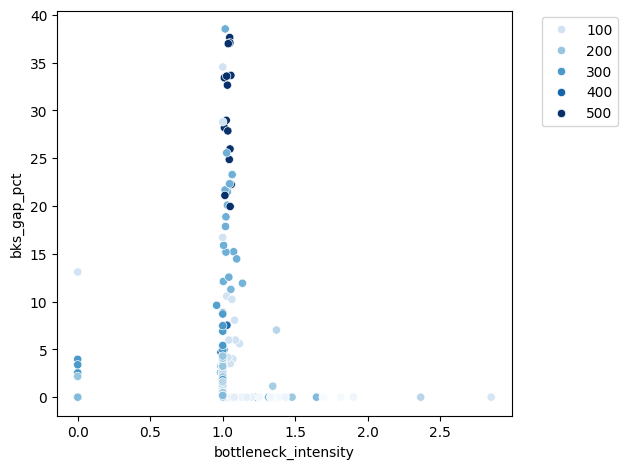

In [32]:
# PLOT TO SHOW AS TO WHY bottleneck_intensity metric is underutilised.
sns.scatterplot(
    data=new_df, 
    x='bottleneck_intensity',
    y='bks_gap_pct', 
    hue='n_operations', 
    palette='Blues',
    sizes=(5, 400) 
)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [37]:
#VERY HIGH CORRELATION
#processing_gap_ratio uses min(t)/max(t) but time skew is a distribution that covers all times.
#Such a high correlation between these parameters was unexpected. This directly points to the dataset nature.
corr=df['time_skew'].corr(df['processing_gap_ratio'])
print(corr)

-0.9847319775095218
